# Inversión del espesor de una bicapa mediante el peso exponencial $w(d)$

Este notebook desarrolla, aplica y valida la ruta estacionaria

$$
\eta(q;d)\;\longrightarrow\;w(d)\;\longrightarrow\;\widehat d
$$

para las campañas `matched_mus` de `luminis-mc`. El objetivo es estimar el espesor $d$ de la
**capa de entrada finita**. El medio inferior se modela como semiinfinito; por tanto, aquí no se
invierten dos espesores independientes.

La conclusión metodológica se fija desde el comienzo:

> La ley exponencial es una **calibración empírica** de la transición entre dos controles
> homogéneos conocidos. No es una solución cerrada de la ecuación de transporte vectorial ni una
> medición universal de espesor.

El cuaderno conserva los estilos de las figuras de tesis, trabaja con las intensidades crudas de
las cinco réplicas y propaga la variabilidad de la capa y de ambos controles mediante bootstrap
estratificado.


## 1. Sistema físico e identificabilidad

La muestra simulada tiene una interfaz plana a profundidad $d$:

$$
\begin{cases}
0<z<d, & \text{medio de entrada},\\
z>d, & \text{medio de fondo semiinfinito}.
\end{cases}
$$

La familia iguala el coeficiente de dispersión de ambas especies,

$$
\mu_s^{\rm ent}=\mu_s^{\rm fon},
\qquad
\ell_s^{\rm ent}=\ell_s^{\rm fon}\equiv\ell_s,
$$

pero conserva funciones de fase y anisotropías diferentes. La longitud de transporte es

$$
\ell^*=\frac{\ell_s}{1-g}.
$$

Así se separan dos conceptos:

- $\ell_s$: distancia media entre colisiones;
- $\ell^*$: distancia necesaria para perder memoria direccional.

El problema inverso no es identificable si simultáneamente se desconocen materiales, orden,
$\ell_s$, polarización y espesor. En este notebook se supone que los dos constituyentes, su orden,
sus controles homogéneos y $\ell^*_{\rm ent}$ son conocidos. La única incógnita es $d$.


In [1]:
# ============================================================================
# 0 -- entorno, estilo y convenciones
# ============================================================================
import os, re, sys, warnings
from dataclasses import dataclass, field
from pathlib import Path

sys.path.append(os.path.abspath("../../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, COL
from utils.analysis import cbs_profiles, circular, phi_cut

FIGDIR = Path("figs_tesis_espesor_w")
FIGDIR.mkdir(exist_ok=True)

BASE_PATH = Path("/Users/niaggar/Results")
FOLDERS = {
    "normal":  "study_two_layers_MUS__NORMAL__PCIR__beam2500",
    "inverse": "study_two_layers_MUS__INVERSE__PCIR__beam2500",
}

N_MEDIUM = 1.33
WAVELENGTH = 0.514                 # um
k = 2 * np.pi * N_MEDIUM / WAVELENGTH

Q_FIT = 5.0
Q_BASELINE = 25.0
N_BOOT = 2000
SEED = 20260820

# Ventana preespecificada antes de evaluar la inversión.
W_MIN, W_MAX = 0.05, 0.90

STYLE = {
    "normal":  dict(color=COL[0], marker="o", ls="-",  label="normal: small entry"),
    "inverse": dict(color=COL[1], marker="s", ls="--", label="inverse: large entry"),
}

print(f"k = {k:.4f} um^-1")
print(f"bootstrap = {N_BOOT} remuestreos; ventana útil preespecificada: {W_MIN:.2f} < w < {W_MAX:.2f}")


k = 16.2580 um^-1
bootstrap = 2000 remuestreos; ventana útil preespecificada: 0.05 < w < 0.90


## 2. Observable CBS y controles homogéneos

Para cada espesor se calcula el factor de realce

$$
\eta_d(q)=\frac{C_d(q)}{B_d(q)},
\qquad
q=k\ell^*_{\rm anchor}\theta,
$$

donde $C$ es el acumulador coherente y $B$ el incoherente. La mediana de la cola angular se lleva
a uno. Se usan dos controles medidos con exactamente el mismo detector:

$$
\eta_{\rm ent}(q),\qquad \eta_{\rm fon}(q).
$$

El canal circular se selecciona por reciprocidad: se escoge aquel cuyo ápice homogéneo está más
cerca de $\eta(0)=2$. No se confía en la etiqueta del canal.


In [2]:
# ============================================================================
# 1 -- lectura de campañas y reducción de intensidades
# ============================================================================
@dataclass
class Layer:
    z: float
    keys: list = field(default_factory=list)


@dataclass
class Campaign:
    order: str
    sweep: object
    l_entry: float
    l_back: float
    ls_common: float
    g_entry: float
    g_back: float
    r_entry: float
    r_back: float
    l_anchor: float
    layers: list
    ctrl_entry: list
    ctrl_back: list
    channel: str = ""
    cache: dict = field(default_factory=dict)


def _get(params, names, default=np.nan):
    for name in names:
        for candidate in (name, name.replace(".", "_"), name.replace("_", ".")):
            if candidate in params:
                try:
                    return float(params[candidate])
                except (TypeError, ValueError):
                    return params[candidate]
    return default


def _get_str(params, names, default=""):
    value = _get(params, names, default)
    return value if isinstance(value, str) else default


def load_campaign(order, folder):
    sweep = load_sweep(folder, base_path=BASE_PATH)
    by_z, controls = {}, {"small": [], "large": []}

    for key in sweep.keys():
        params = sweep[key].params_flat
        kind = _get_str(params, ["layer_kind"])
        if kind == "stratified_one_layer" or "single_layer" in key:
            species = _get_str(params, ["single_layer_species"])
            if not species:
                species = "small" if "small" in key else "large"
            controls[species].append(key)
            continue
        z = _get(params, ["z_interface"])
        if not (isinstance(z, float) and np.isfinite(z)):
            match = re.search(r"z_interface_([0-9.]+)__rep(\d+)", key)
            if not match:
                continue
            z = float(match.group(1))
        by_z.setdefault(round(z, 6), []).append(key)

    first_key = sorted(by_z[sorted(by_z)[0]])[0]
    p = sweep[first_key].params_flat
    r_top, r_bot = _get(p, ["radius_top"]), _get(p, ["radius_bot"])
    l_top, l_bot = _get(p, ["l_star_top"]), _get(p, ["l_star_bot"])
    ls_top, ls_bot = _get(p, ["l_s_top"]), _get(p, ["l_s_bot"])
    ls_common = 0.5 * (ls_top + ls_bot)
    if abs(ls_top - ls_bot) / ls_common > 1e-4:
        raise RuntimeError(f"{order}: l_s no está igualado")

    g_top = 1.0 - ls_top / l_top
    g_bot = 1.0 - ls_bot / l_bot
    entry_species = "large" if r_top > r_bot else "small"
    back_species = "small" if entry_species == "large" else "large"
    layers = [Layer(z=z, keys=sorted(by_z[z])) for z in sorted(by_z)]

    return Campaign(
        order=order, sweep=sweep, l_entry=l_top, l_back=l_bot,
        ls_common=ls_common, g_entry=g_top, g_back=g_bot,
        r_entry=r_top, r_back=r_bot,
        l_anchor=_get(p, ["l_star_angle_anchor"], min(l_top, l_bot)),
        layers=layers,
        ctrl_entry=sorted(controls[entry_species]),
        ctrl_back=sorted(controls[back_species]),
    )


def _channel_names(profile):
    obj = profile.coherent
    try:
        return list(obj.keys())
    except AttributeError:
        return [name for name in dir(obj) if not name.startswith("_")]


def _channel_get(profile, channel, which):
    obj = getattr(profile, which)
    try:
        return np.asarray(obj[channel], float)
    except (TypeError, KeyError):
        return np.asarray(getattr(obj, channel), float)


def raw_components(campaign, key, channel):
    cache_key = (key, channel)
    if cache_key in campaign.cache:
        return campaign.cache[cache_key]

    processed_1 = campaign.sweep[key].processed_cbs("farfield_cbs_1")
    processed_2 = campaign.sweep[key].processed_cbs("farfield_cbs_2")
    p1 = cbs_profiles(processed_1, basis=circular, time_index=0, reduce=phi_cut(0))
    p2 = cbs_profiles(processed_2, basis=circular, time_index=0, reduce=phi_cut(0))

    th1, th2 = np.asarray(p1.theta), np.asarray(p2.theta)
    keep2 = th2 > th1[-1]
    theta = np.concatenate([th1, th2[keep2]])
    coherent = np.concatenate([
        _channel_get(p1, channel, "coherent"),
        _channel_get(p2, channel, "coherent")[keep2],
    ])
    incoherent = np.concatenate([
        _channel_get(p1, channel, "incoherent"),
        _channel_get(p2, channel, "incoherent")[keep2],
    ])
    q = k * campaign.l_anchor * theta
    campaign.cache[cache_key] = (q, coherent, incoherent)
    return campaign.cache[cache_key]


def profile_from_keys(campaign, keys, channel=None):
    channel = campaign.channel if channel is None else channel
    arrays = [raw_components(campaign, key, channel) for key in keys]
    q = arrays[0][0]
    coherent = np.sum([item[1] for item in arrays], axis=0)
    incoherent = np.sum([item[2] for item in arrays], axis=0)
    eta = coherent / np.maximum(incoherent, 1e-30)
    tail = q > Q_BASELINE
    baseline = np.median(eta[tail]) if np.count_nonzero(tail) >= 5 else np.median(eta[-20:])
    return q, eta - baseline + 1.0


def resolve_channel(campaign):
    key = campaign.ctrl_entry[0]
    processed = campaign.sweep[key].processed_cbs("farfield_cbs_1")
    profile = cbs_profiles(processed, basis=circular, time_index=0, reduce=phi_cut(0))
    apex = {}
    for channel in _channel_names(profile):
        try:
            _, eta = profile_from_keys(campaign, [key], channel=channel)
            apex[channel] = float(np.mean(eta[:3]))
        except Exception:
            pass
    if not apex:
        raise RuntimeError(f"{campaign.order}: no se pudo resolver el canal")
    selected = min(apex, key=lambda name: abs(apex[name] - 2.0))
    print(f"{campaign.order:7s}: canales {apex} -> '{selected}'")
    return selected


In [3]:
# ============================================================================
# 2 -- carga y compuertas físicas
# ============================================================================
CAMP = {order: load_campaign(order, folder) for order, folder in FOLDERS.items()}
for campaign in CAMP.values():
    campaign.channel = resolve_channel(campaign)

system_rows = []
for order, campaign in CAMP.items():
    system_rows.append({
        "order": order,
        "r_entry_nm": 1e3 * campaign.r_entry,
        "r_back_nm": 1e3 * campaign.r_back,
        "l_s_um": campaign.ls_common,
        "l_star_entry_um": campaign.l_entry,
        "l_star_back_um": campaign.l_back,
        "g_entry": campaign.g_entry,
        "g_back": campaign.g_back,
        "n_thickness": len(campaign.layers),
        "n_replica": len(campaign.layers[0].keys),
    })

SYSTEM = pd.DataFrame(system_rows)
print("\nSistema cargado:")
print(SYSTEM.round(4).to_string(index=False))
print("\nEspesores d/l_s:")
for order, campaign in CAMP.items():
    values = [layer.z / campaign.ls_common for layer in campaign.layers]
    print(f"  {order:7s}: {np.round(values, 3)}")


normal : canales {'co': 1.3244922802211978, 'cross': 1.9809029534362625, 'total': 1.5307010486116541} -> 'cross'
inverse: canales {'co': 1.283638243523867, 'cross': 1.9863080655391672, 'total': 1.570937531387086} -> 'cross'

Sistema cargado:
  order  r_entry_nm  r_back_nm   l_s_um  l_star_entry_um  l_star_back_um  g_entry  g_back  n_thickness  n_replica
 normal        35.0      100.0 111.6658         118.0352        215.3057   0.0540  0.4814           10          5
inverse       100.0       35.0 111.6658         215.4441        118.1349   0.4817  0.0548           10          5

Espesores d/l_s:
  normal : [ 0.    0.1   0.25  0.5   1.    2.    3.    5.    7.   10.  ]
  inverse: [ 0.    0.1   0.25  0.5   1.    2.    3.    5.    7.   10.  ]


## 3. Definición matemática del peso $w$

Se define el exceso sobre la línea base,

$$
F_d(q)=\eta_d(q)-1,
\quad
F_e(q)=\eta_{\rm ent}(q)-1,
\quad
F_f(q)=\eta_{\rm fon}(q)-1.
$$

El modelo de dos controles es

$$
F_d(q)\simeq F_f(q)+w(d)[F_e(q)-F_f(q)].
$$

Minimizando

$$
\mathcal R(w)=\sum_{q_j\leq q_{\rm fit}}
\left\{F_d(q_j)-F_f(q_j)-w[F_e(q_j)-F_f(q_j)]\right\}^2,
$$

se obtiene

$$
\boxed{
\widehat w=
\frac{\sum_j[F_d(q_j)-F_f(q_j)][F_e(q_j)-F_f(q_j)]}
{\sum_j[F_e(q_j)-F_f(q_j)]^2}}
$$

$w$ es una coordenada de similitud en el espacio de perfiles. No se fuerza a $[0,1]$: que algún
valor salga de ese intervalo es una alerta de que no debe interpretarse como probabilidad de
permanecer en la capa. El residuo contiene caminos híbridos y el error de superponer cocientes
$C/B$.


In [4]:
# ============================================================================
# 3 -- perfiles, peso central y bootstrap estratificado
# ============================================================================
def on_grid(q, eta, q_ref):
    if len(q) == len(q_ref) and np.allclose(q, q_ref):
        return eta
    return np.interp(q_ref, q, eta)


def fit_weight(q, eta, eta_entry, eta_back):
    mask = q <= Q_FIT
    y = eta - 1.0
    fe = eta_entry - 1.0
    fb = eta_back - 1.0
    delta = (fe - fb)[mask]
    w = np.sum((y - fb)[mask] * delta) / np.sum(delta**2)
    residual = (y - fb - w * (fe - fb))[mask]
    return float(w), float(np.sqrt(np.mean(residual**2)))


def component_stack(campaign, keys):
    arrays = [raw_components(campaign, key, campaign.channel) for key in keys]
    q = arrays[0][0]
    coherent = np.stack([item[1] for item in arrays])
    incoherent = np.stack([item[2] for item in arrays])
    return q, coherent, incoherent


def bootstrap_profiles(q, coherent, incoherent, indices):
    csum = coherent[indices].sum(axis=1)
    bsum = incoherent[indices].sum(axis=1)
    eta = csum / np.maximum(bsum, 1e-30)
    tail = q > Q_BASELINE
    if np.count_nonzero(tail) < 5:
        tail = np.arange(len(q)) >= len(q) - 20
    baseline = np.median(eta[:, tail], axis=1)
    return eta - baseline[:, None] + 1.0


rng = np.random.default_rng(SEED)
PROFILE = {}
WEIGHT_ROWS = []
W_BOOT = {}

for order, campaign in CAMP.items():
    q_entry, eta_entry = profile_from_keys(campaign, campaign.ctrl_entry)
    q_back, eta_back = profile_from_keys(campaign, campaign.ctrl_back)
    eta_back = on_grid(q_back, eta_back, q_entry)
    PROFILE[(order, "entry")] = (q_entry, eta_entry)
    PROFILE[(order, "back")] = (q_entry, eta_back)

    q_e, c_e, b_e = component_stack(campaign, campaign.ctrl_entry)
    q_f, c_f, b_f = component_stack(campaign, campaign.ctrl_back)
    idx_e = rng.integers(0, len(c_e), size=(N_BOOT, len(c_e)))
    idx_f = rng.integers(0, len(c_f), size=(N_BOOT, len(c_f)))
    boot_entry = bootstrap_profiles(q_e, c_e, b_e, idx_e)
    boot_back = bootstrap_profiles(q_f, c_f, b_f, idx_f)
    if not np.allclose(q_e, q_f):
        boot_back = np.stack([np.interp(q_e, q_f, row) for row in boot_back])

    mask = q_e <= Q_FIT
    for layer in campaign.layers:
        q_d, eta_d = profile_from_keys(campaign, layer.keys)
        eta_d_ref = on_grid(q_d, eta_d, q_entry)
        w, rms = fit_weight(q_entry, eta_d_ref, eta_entry, eta_back)
        PROFILE[(order, layer.z)] = (q_entry, eta_d_ref)

        q_l, c_l, b_l = component_stack(campaign, layer.keys)
        idx_l = rng.integers(0, len(c_l), size=(N_BOOT, len(c_l)))
        boot_layer = bootstrap_profiles(q_l, c_l, b_l, idx_l)
        if not np.allclose(q_l, q_e):
            boot_layer = np.stack([np.interp(q_e, q_l, row) for row in boot_layer])

        fe = boot_entry - 1.0
        ff = boot_back - 1.0
        yd = boot_layer - 1.0
        delta = (fe - ff)[:, mask]
        wb = np.sum((yd - ff)[:, mask] * delta, axis=1) / np.sum(delta**2, axis=1)
        W_BOOT[(order, layer.z)] = wb

        WEIGHT_ROWS.append({
            "order": order,
            "z_um": layer.z,
            "m_s": layer.z / campaign.ls_common,
            "m_star": layer.z / campaign.l_entry,
            "w": w,
            "w_sd": np.std(wb, ddof=1),
            "w_lo95": np.quantile(wb, 0.025),
            "w_hi95": np.quantile(wb, 0.975),
            "rms": rms,
        })

WEIGHTS = pd.DataFrame(WEIGHT_ROWS).sort_values(["order", "z_um"]).reset_index(drop=True)
WEIGHTS.to_csv(FIGDIR / "tabla_pesos_w.csv", index=False)
print(WEIGHTS.round(5).to_string(index=False))


  order       z_um      m_s  m_star       w    w_sd   w_lo95  w_hi95     rms
inverse    0.00112  0.00001 0.00001 0.00535 0.03227 -0.05533 0.06737 0.00508
inverse   11.16658  0.10000 0.05183 0.16012 0.03580  0.07798 0.21872 0.01339
inverse   27.91646  0.25000 0.12958 0.27155 0.02558  0.22376 0.31752 0.02164
inverse   55.83291  0.50000 0.25915 0.42790 0.02091  0.38764 0.46830 0.02278
inverse  111.66582  1.00000 0.51831 0.68658 0.01930  0.64370 0.71858 0.03027
inverse  223.33165  2.00000 1.03661 0.91653 0.01429  0.89101 0.94702 0.01709
inverse  334.99747  3.00000 1.55492 1.00110 0.01145  0.97942 1.02409 0.00968
inverse  558.32912  5.00000 2.59153 1.07135 0.02218  1.02750 1.11355 0.00356
inverse  781.66077  7.00000 3.62814 0.98822 0.01784  0.96678 1.03518 0.00284
inverse 1116.65824 10.00000 5.18305 1.03216 0.02474  0.98924 1.08721 0.00570
 normal    0.00112  0.00001 0.00001 0.00457 0.01966 -0.04083 0.03692 0.00437
 normal   11.16658  0.10000 0.09460 0.16471 0.01306  0.14466 0.19484 0.00917

## 4. De $w$ al espesor: modelo exponencial

La hipótesis empírica es que la fracción todavía no convertida al perfil de entrada decrece con
una tasa efectiva constante:

$$
\frac{d(1-w)}{dm}=-\frac{1-w}{\lambda},
\qquad
m=\frac{d}{\ell^*_{\rm ent}}.
$$

Con $w(0)=0$,

$$
\boxed{w(m)=1-e^{-m/\lambda}}.
$$

La escala dimensional de sensibilidad es

$$
L_{\rm eff}=\lambda\ell^*_{\rm ent},
$$

y la inversión es

$$
\boxed{\widehat d=-L_{\rm eff}\ln(1-\widehat w)}.
$$

Esta ecuación se usa como calibración empírica de los datos simulados. El parámetro
$L_{\rm eff}$ es la escala a la cual el perfil pierde sensibilidad al medio enterrado; incorpora
el material de entrada, el orden, la polarización y el procedimiento de reducción.

### Propagación de incertidumbre

Para $d=-\lambda\ell^*\ln(1-w)$,

$$
\sigma_d^2\simeq
\left(\frac{\lambda\ell^*}{1-w}\sigma_w\right)^2+
\left(\frac{d}{\lambda}\sigma_\lambda\right)^2.
$$

La derivada $\partial d/\partial w=L_{\rm eff}/(1-w)$ diverge cuando $w\to1$: ése es el límite
fundamental de la inversión por saturación.


In [5]:
# ============================================================================
# 4 -- calibración exponencial
# ============================================================================
def w_exp(m, lam):
    return 1.0 - np.exp(-np.asarray(m) / lam)


FIT_ROWS = []
FITS = {}
for order, group in WEIGHTS.groupby("order"):
    campaign = CAMP[order]
    good = (group["m_star"] > 1e-3) & np.isfinite(group["w"]) & (group["w_sd"] > 0)
    m = group.loc[good, "m_star"].to_numpy()
    w = group.loc[good, "w"].to_numpy()
    sigma = np.maximum(group.loc[good, "w_sd"].to_numpy(), 1e-3)

    popt, pcov = curve_fit(
        w_exp, m, w, p0=[0.5], sigma=sigma, absolute_sigma=True,
        bounds=(1e-4, np.inf), maxfev=40000,
    )
    lam = float(popt[0])
    s_lam = float(np.sqrt(pcov[0, 0]))
    chi2 = float(np.sum(((w - w_exp(m, lam)) / sigma)**2))
    ndf = len(m) - 1
    l_eff = lam * campaign.l_entry

    FITS[order] = dict(
        lam=lam, s_lam=s_lam, chi2_exp=chi2, ndf=ndf, l_eff=l_eff,
    )
    FIT_ROWS.append({
        "order": order,
        "lambda_star": lam,
        "s_lambda_star": s_lam,
        "L_eff_um": l_eff,
        "L_eff_over_ls": l_eff / campaign.ls_common,
        "chi2_ndf_exp": chi2 / ndf,
    })

FIT_TABLE = pd.DataFrame(FIT_ROWS)
FIT_TABLE.to_csv(FIGDIR / "tabla_calibracion_exponencial.csv", index=False)
print(FIT_TABLE.round(4).to_string(index=False))


  order  lambda_star  s_lambda_star  L_eff_um  L_eff_over_ls  chi2_ndf_exp
inverse       0.4279         0.0137   92.1873         0.8256        2.8889
 normal       0.5819         0.0222   68.6833         0.6151        1.4288


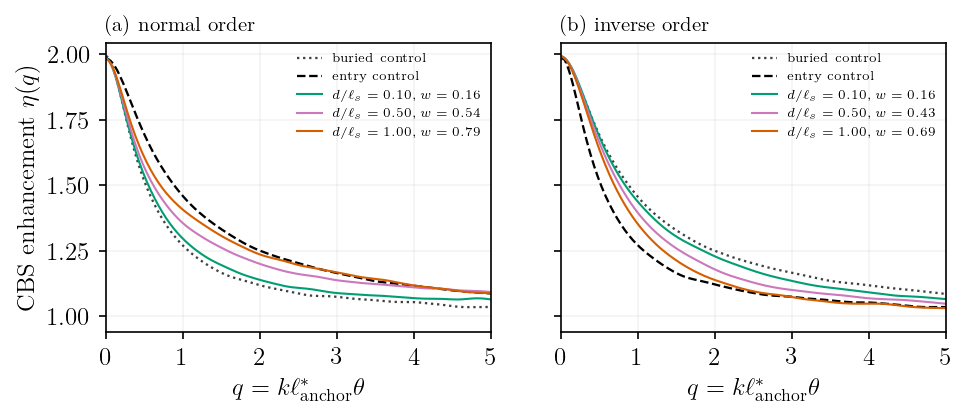

In [6]:
# ============================================================================
# F1 -- evolución de los conos y significado geométrico de w
# ============================================================================
apply(width_frac=1.0)
fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN),
                         sharey=True, gridspec_kw={"wspace": 0.12})

targets = [0.10, 0.50, 1.00]
for ax, order in zip(axes, ["normal", "inverse"]):
    campaign = CAMP[order]
    q, eta_entry = PROFILE[(order, "entry")]
    _, eta_back = PROFILE[(order, "back")]
    ax.plot(q, eta_back, color="0.25", lw=1.1, ls=":", label="buried control")
    ax.plot(q, eta_entry, color="k", lw=1.1, ls="--", label="entry control")

    group = WEIGHTS[WEIGHTS["order"] == order]
    colors = [COL[2], COL[4], COL[3]]
    for target, color in zip(targets, colors):
        row = group.iloc[np.argmin(np.abs(group["m_s"].to_numpy() - target))]
        qd, eta = PROFILE[(order, row["z_um"])]
        ax.plot(qd, eta, color=color, lw=1.0,
                label=rf"$d/\ell_s={row['m_s']:.2f}$, $w={row['w']:.2f}$")

    ax.set_xlim(0, Q_FIT)
    ax.set_xlabel(r"$q=k\ell^*_{\rm anchor}\theta$")
    ax.set_title(f"({chr(97 + list(axes).index(ax))}) {order} order", loc="left", fontsize="small")
    ax.grid(alpha=0.15)
    ax.legend(fontsize=6, frameon=False)

axes[0].set_ylabel(r"CBS enhancement $\eta(q)$")
fig.savefig(FIGDIR / "F1_perfiles_y_peso.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "F1_perfiles_y_peso.png", dpi=220, bbox_inches="tight")
plt.show()


**Figura F1 — Evolución del perfil y significado de $w$.** Los controles homogéneos fijan los
límites $w=0$ (fondo) y $w=1$ (entrada). Las curvas intermedias muestran cómo el cono de la bicapa
se desplaza entre ambos perfiles al aumentar $d$. El peso se obtiene de la forma angular completa
en $q\leq5$; no corresponde a un único valor del ápice.


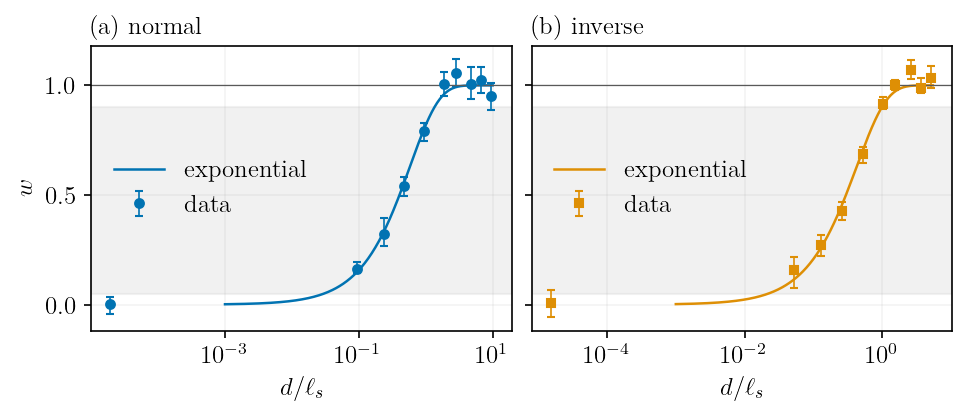

In [16]:
# ============================================================================
# F2 -- calibración de w(d) con el modelo exponencial
# ============================================================================
apply(width_frac=1.0)
fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN),
                         sharey=True)

for ax, order in zip(axes, ["normal", "inverse"]):
    group = WEIGHTS[WEIGHTS["order"] == order]
    fit = FITS[order]
    style = STYLE[order]
    m = group["m_star"].to_numpy()
    yerr = np.vstack([group["w"] - group["w_lo95"], group["w_hi95"] - group["w"]])
    ax.errorbar(m + 1e-5, group["w"], yerr=yerr, fmt=style["marker"], ms=4.2,
                color=style["color"], elinewidth=0.8, capsize=2,
                label=r"data")

    grid = np.geomspace(1e-3, max(m) * 1.05, 300)
    ax.plot(grid, w_exp(grid, fit["lam"]), color=style["color"], lw=1.2,
            label=rf"exponential")
    ax.axhspan(W_MIN, W_MAX, color="0.85", alpha=0.35, zorder=0)
    ax.axhline(1.0, color="0.35", lw=0.6)
    ax.set_xscale("log")
    ax.set_ylim(-0.12, 1.18)
    ax.set_xlabel(r"$d/\ell_{s}$")
    ax.set_title(
        f"({chr(97 + list(axes).index(ax))}) {order}",
        loc="left"
    )
    ax.grid(alpha=0.15, which="both")
    ax.legend(frameon=False, loc="center left")

axes[0].set_ylabel(r"$w$")
fig.savefig(FIGDIR / "F2_calibracion_exponencial.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "F2_calibracion_exponencial.png", dpi=220, bbox_inches="tight")
plt.show()


**Figura F2 — Calibración del modelo de espesor.** Los puntos y sus intervalos incluyen el
remuestreo independiente de la bicapa y de los dos controles. La curva continua es el ajuste
$w=1-e^{-m/\lambda}$. La banda gris no es un intervalo de confianza: marca la ventana de $w$
declarada para la inversión. El orden inverso conserva $\chi_\nu^2>1$ y, por tanto, evidencia
dispersión no explicada por una sola escala $\lambda$.


## 5. Validación leave-one-out y ventana útil

Para cada espesor $d_i$ se elimina ese punto, se recalibra $\lambda_{(-i)}$ con los demás y se
invierte $w_i$. Esto evita ajustar la escala con el mismo punto que se quiere recuperar:

$$
\widehat d_i=-\lambda_{(-i)}\ell^*_{\rm ent}\ln(1-w_i).
$$

La validación sigue siendo **interna**: los controles, materiales, orden y campaña son conocidos.
No prueba transferencia a otra geometría.

Se declara antes de mirar los errores la ventana

$$
0.05<w<0.90.
$$

Por debajo, el cambio de perfil compite con la incertidumbre de los controles; por encima, la
saturación amplifica fuertemente cualquier error. Los puntos fuera de la ventana se muestran, pero
no se usan para citar precisión metrológica.


In [8]:
# ============================================================================
# 5 -- inversión leave-one-out
# ============================================================================
INVERSION_ROWS = []

for order, group_original in WEIGHTS.groupby("order"):
    campaign = CAMP[order]
    group = group_original.reset_index(drop=True)
    for i, row in group.iterrows():
        train = (group["m_star"] > 1e-3) & np.isfinite(group["w"]) & (group["w_sd"] > 0)
        train.iloc[i] = False
        if train.sum() < 3:
            continue

        m_train = group.loc[train, "m_star"].to_numpy()
        w_train = group.loc[train, "w"].to_numpy()
        s_train = np.maximum(group.loc[train, "w_sd"].to_numpy(), 1e-3)
        popt, pcov = curve_fit(
            w_exp, m_train, w_train, p0=[FITS[order]["lam"]],
            sigma=s_train, absolute_sigma=True, bounds=(1e-4, np.inf), maxfev=40000,
        )
        lam = float(popt[0])
        s_lam = float(np.sqrt(pcov[0, 0]))
        w_i = float(row["w"])
        valid_log = 0.0 < w_i < 1.0
        useful = valid_log and (W_MIN < w_i < W_MAX)

        if valid_log:
            m_hat = -lam * np.log(1.0 - w_i)
            d_hat = m_hat * campaign.l_entry
            s_m = np.hypot(
                lam / (1.0 - w_i) * row["w_sd"],
                (m_hat / lam) * s_lam,
            )
            s_d = s_m * campaign.l_entry
            rel_error = d_hat / row["z_um"] - 1.0 if row["z_um"] > 0.01 else np.nan
        else:
            d_hat = s_d = rel_error = np.nan

        INVERSION_ROWS.append({
            "order": order,
            "z_true_um": row["z_um"],
            "m_s_true": row["m_s"],
            "w": w_i,
            "lambda_loo": lam,
            "s_lambda_loo": s_lam,
            "d_hat_um": d_hat,
            "s_d_um": s_d,
            "relative_error": rel_error,
            "useful_window": useful,
        })

INVERSION = pd.DataFrame(INVERSION_ROWS)
INVERSION.to_csv(FIGDIR / "tabla_inversion_leave_one_out.csv", index=False)

summary_rows = []
for order, group in INVERSION[INVERSION["useful_window"]].groupby("order"):
    err = group["relative_error"].dropna()
    summary_rows.append({
        "order": order,
        "n_useful": len(err),
        "d_min_um": group["z_true_um"].min(),
        "d_max_um": group["z_true_um"].max(),
        "median_abs_error_pct": 100 * np.median(np.abs(err)),
        "max_abs_error_pct": 100 * np.max(np.abs(err)),
        "rmse_pct": 100 * np.sqrt(np.mean(err**2)),
    })

VALIDATION = pd.DataFrame(summary_rows)
VALIDATION.to_csv(FIGDIR / "tabla_validacion_ventana_util.csv", index=False)
print("Validación dentro de la ventana preespecificada:")
print(VALIDATION.round(3).to_string(index=False))


Validación dentro de la ventana preespecificada:
  order  n_useful  d_min_um  d_max_um  median_abs_error_pct  max_abs_error_pct  rmse_pct
inverse         4    11.167   111.666                 8.214             44.591    23.216
 normal         4    11.167   111.666                 5.731             12.908     7.971


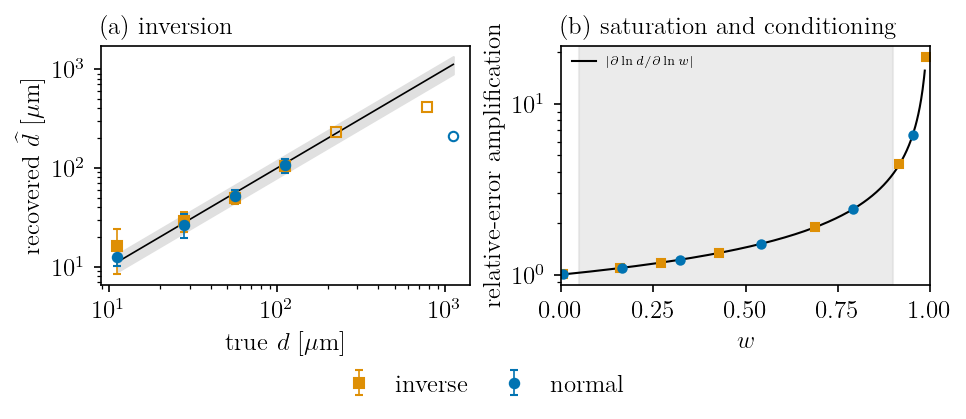

In [26]:
# ============================================================================
# F3 -- inversión y condicionamiento
# ============================================================================
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.43 * TEXTWIDTH_IN))

valid_points = INVERSION[np.isfinite(INVERSION["d_hat_um"]) & (INVERSION["z_true_um"] > 0.01)]
zmin, zmax = valid_points["z_true_um"].min(), valid_points["z_true_um"].max()
identity = np.geomspace(zmin, zmax, 200)
ax1.plot(identity, identity, "k-", lw=0.8)
ax1.fill_between(identity, 0.8 * identity, 1.2 * identity, color="0.88")

for order, group in valid_points.groupby("order"):
    style = STYLE[order]
    useful = group["useful_window"]

    ax1.errorbar(
        group.loc[useful, "z_true_um"], group.loc[useful, "d_hat_um"],
        yerr=1.96 * group.loc[useful, "s_d_um"], fmt=style["marker"], ms=4.5,
        color=style["color"], elinewidth=0.8, capsize=2, label=f"{order}",
    )
    ax1.plot(
        group.loc[~useful, "z_true_um"], group.loc[~useful, "d_hat_um"],
        style["marker"], ms=4.5, mfc="none", mec=style["color"],
    )

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"true $d$ [$\mu$m]")
ax1.set_ylabel(r"recovered $\widehat d$ [$\mu$m]")
ax1.set_title("(a) inversion", loc="left")

w_grid = np.linspace(0.01, 0.985, 500)
amplification = w_grid / ((1.0 - w_grid) * (-np.log(1.0 - w_grid)))
ax2.plot(w_grid, amplification, "k-", lw=1.0,
         label=r"$\left|\partial\ln d/\partial\ln w\right|$")
ax2.axvspan(W_MIN, W_MAX, color="0.85", alpha=0.5)
for order, group in WEIGHTS.groupby("order"):
    style = STYLE[order]
    physical = (group["w"] > 0) & (group["w"] < 1)
    ww = group.loc[physical, "w"]
    aa = ww / ((1.0 - ww) * (-np.log(1.0 - ww)))
    ax2.plot(ww, aa, style["marker"], color=style["color"], ms=4)

ax2.set_yscale("log")
ax2.set_xlim(0, 1.0)
ax2.set_xlabel(r"$w$")
ax2.set_ylabel("relative-error amplification")
ax2.set_title("(b) saturation and conditioning", loc="left")
ax2.legend(fontsize=5.8, frameon=False)

fig.legend(*ax1.get_legend_handles_labels(), ncol=3, loc="outside lower center",
               frameon=False, columnspacing=1.2, handlelength=1.3)

fig.savefig(FIGDIR / "F3_inversion_y_condicionamiento.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "F3_inversion_y_condicionamiento.png", dpi=220, bbox_inches="tight")
plt.show()


**Figura F3 — Validación y condicionamiento.** Los símbolos llenos satisfacen la ventana
$0.05<w<0.90$; los abiertos se muestran como diagnóstico de extrapolación o saturación. El panel
(b) representa el factor $|\partial\ln d/\partial\ln w|$: cuando $w\to1$, una variación pequeña del
peso produce una variación grande del espesor. Esta divergencia explica por qué el método debe
reportar un rango útil y no sólo una curva invertible.


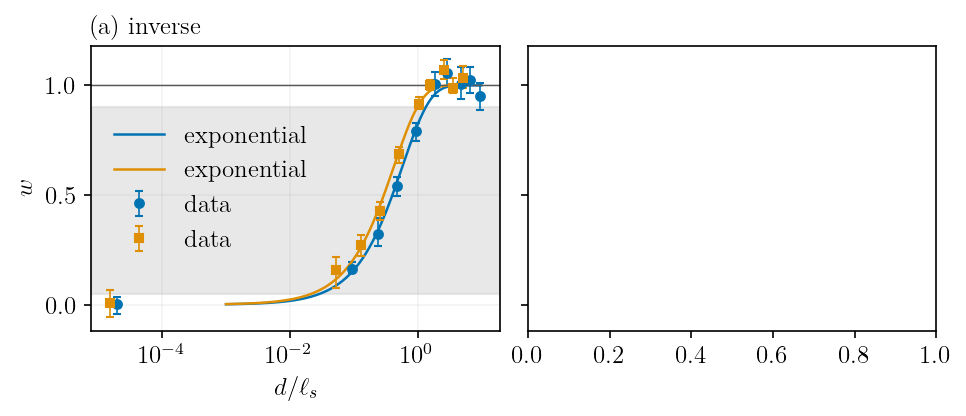

In [28]:
# ============================================================================
# F2 -- calibración de w(d) con el modelo exponencial
# ============================================================================
apply(width_frac=1.0)
fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN),
                         sharey=True)

for order in ["normal", "inverse"]:
    ax = axes[0]
    group = WEIGHTS[WEIGHTS["order"] == order]
    fit = FITS[order]
    style = STYLE[order]
    m = group["m_star"].to_numpy()
    yerr = np.vstack([group["w"] - group["w_lo95"], group["w_hi95"] - group["w"]])
    ax.errorbar(m + 1e-5, group["w"], yerr=yerr, fmt=style["marker"], ms=4.2,
                color=style["color"], elinewidth=0.8, capsize=2,
                label=r"data")

    grid = np.geomspace(1e-3, max(m) * 1.05, 300)
    ax.plot(grid, w_exp(grid, fit["lam"]), color=style["color"], lw=1.2,
            label=rf"exponential")
    ax.axhspan(W_MIN, W_MAX, color="0.85", alpha=0.35, zorder=0)
    ax.axhline(1.0, color="0.35", lw=0.6)
    ax.set_xscale("log")
    ax.set_ylim(-0.12, 1.18)
    ax.set_xlabel(r"$d/\ell_{s}$")
    ax.set_title(
        f"(a) {order}",
        loc="left"
    )
    ax.grid(alpha=0.15, which="both")
    ax.legend(frameon=False, loc="center left")

axes[0].set_ylabel(r"$w$")
fig.savefig(FIGDIR / "F2_calibracion_exponencial_inversion.pdf", bbox_inches="tight")
plt.show()


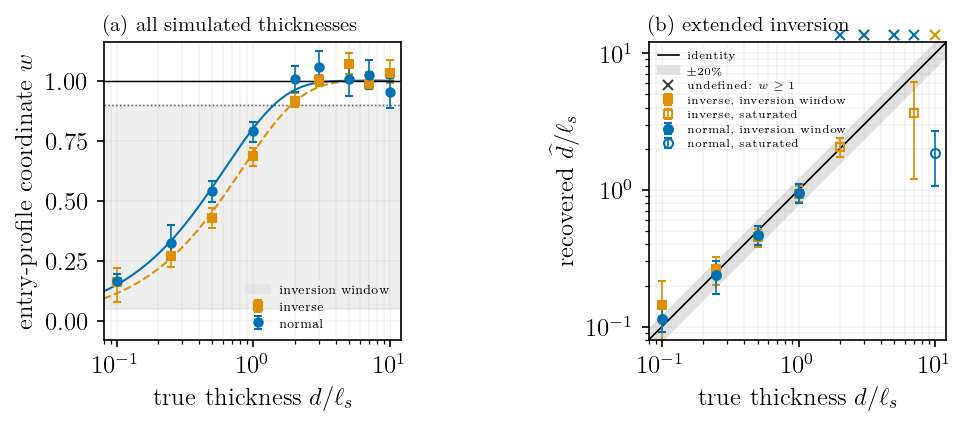

Inversión extendida hasta d/l_s = 10:
  order  m_s_true      w  d_hat_over_ls  relative_error        classification
inverse      0.10 0.1601         0.1446          0.4459      inversion window
inverse      0.25 0.2716         0.2625          0.0500      inversion window
inverse      0.50 0.4279         0.4493         -0.1015      inversion window
inverse      1.00 0.6866         0.9372         -0.0628      inversion window
inverse      2.00 0.9165         2.0639          0.0320 saturated but defined
inverse      3.00 1.0011            NaN             NaN     undefined: w >= 1
inverse      5.00 1.0714            NaN             NaN     undefined: w >= 1
inverse      7.00 0.9882         3.6666         -0.4762 saturated but defined
inverse     10.00 1.0322            NaN             NaN     undefined: w >= 1
 normal      0.10 0.1647         0.1129          0.1291      inversion window
 normal      0.25 0.3226         0.2385         -0.0458      inversion window
 normal      0.50 0.5420  

In [10]:
# ============================================================================
# F4 -- inversión extendida hasta el máximo espesor de la simulación
# ============================================================================
EXTENDED = INVERSION.copy()
EXTENDED["d_hat_over_ls"] = np.nan
EXTENDED["s_d_over_ls"] = np.nan
EXTENDED["classification"] = "undefined"

for i, row in EXTENDED.iterrows():
    ls = CAMP[row["order"]].ls_common
    if np.isfinite(row["d_hat_um"]):
        EXTENDED.loc[i, "d_hat_over_ls"] = row["d_hat_um"] / ls
        EXTENDED.loc[i, "s_d_over_ls"] = row["s_d_um"] / ls
    if row["useful_window"]:
        EXTENDED.loc[i, "classification"] = "inversion window"
    elif 0.0 < row["w"] <= W_MIN:
        EXTENDED.loc[i, "classification"] = "low sensitivity"
    elif W_MAX <= row["w"] < 1.0:
        EXTENDED.loc[i, "classification"] = "saturated but defined"
    elif row["w"] >= 1.0:
        EXTENDED.loc[i, "classification"] = "undefined: w >= 1"

EXTENDED.to_csv(FIGDIR / "tabla_inversion_extendida.csv", index=False)

apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(TEXTWIDTH_IN, 0.43 * TEXTWIDTH_IN),
    gridspec_kw={"wspace": 0.30},
)

# Panel (a): todos los pesos no nulos hasta d/l_s = 10.
for order, group in WEIGHTS.groupby("order"):
    campaign = CAMP[order]
    style = STYLE[order]
    shown = group["m_s"] >= 0.09
    data = group[shown]
    yerr = np.vstack([data["w"] - data["w_lo95"], data["w_hi95"] - data["w"]])
    ax1.errorbar(
        data["m_s"], data["w"], yerr=yerr,
        fmt=style["marker"], ms=4.0, color=style["color"],
        elinewidth=0.8, capsize=2, label=order,
    )
    grid_s = np.geomspace(0.08, 10.5, 300)
    grid_star = grid_s * campaign.ls_common / campaign.l_entry
    ax1.plot(
        grid_s, w_exp(grid_star, FITS[order]["lam"]),
        style["ls"], color=style["color"], lw=1.0,
    )

ax1.axhspan(W_MIN, W_MAX, color="0.88", alpha=0.55, label="inversion window")
ax1.axhline(W_MAX, color="0.35", lw=0.7, ls=":")
ax1.axhline(1.0, color="k", lw=0.7)
ax1.set_xscale("log")
ax1.set_xlim(0.08, 12)
ax1.set_ylim(-0.08, 1.16)
ax1.set_xlabel(r"true thickness $d/\ell_s$")
ax1.set_ylabel(r"entry-profile coordinate $w$")
ax1.set_title("(a) all simulated thicknesses", loc="left", fontsize="small")
ax1.grid(alpha=0.15, which="both")
ax1.legend(fontsize=5.8, frameon=False, loc="lower right")

# Panel (b): inversión donde el logaritmo es real; los w>=1 se marcan arriba.
identity = np.geomspace(0.08, 12, 300)
ax2.plot(identity, identity, "k-", lw=0.8, label="identity")
ax2.fill_between(identity, 0.8 * identity, 1.2 * identity, color="0.88", label=r"$\pm20\%$")

for order, group in EXTENDED.groupby("order"):
    style = STYLE[order]
    group = group[group["m_s_true"] >= 0.09]
    useful = group["classification"] == "inversion window"
    saturated = group["classification"] == "saturated but defined"
    undefined = group["classification"] == "undefined: w >= 1"

    ax2.errorbar(
        group.loc[useful, "m_s_true"], group.loc[useful, "d_hat_over_ls"],
        yerr=1.96 * group.loc[useful, "s_d_over_ls"],
        fmt=style["marker"], ms=4.3, color=style["color"],
        elinewidth=0.8, capsize=2, label=f"{order}, inversion window",
    )
    ax2.errorbar(
        group.loc[saturated, "m_s_true"], group.loc[saturated, "d_hat_over_ls"],
        yerr=1.96 * group.loc[saturated, "s_d_over_ls"],
        fmt=style["marker"], ms=4.3, mfc="none", mec=style["color"],
        ecolor=style["color"], elinewidth=0.8, capsize=2,
        label=f"{order}, saturated",
    )
    ax2.plot(
        group.loc[undefined, "m_s_true"], np.full(undefined.sum(), 1.025),
        "x", color=style["color"], ms=5, mew=1.0,
        transform=ax2.get_xaxis_transform(), clip_on=False,
    )

# Entrada de leyenda común para los puntos cuya inversión no es real.
ax2.plot([], [], "x", color="0.25", ms=5, label=r"undefined: $w\geq1$")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(0.08, 12)
ax2.set_ylim(0.08, 12)
ax2.set_xlabel(r"true thickness $d/\ell_s$")
ax2.set_ylabel(r"recovered $\widehat d/\ell_s$")
ax2.set_title("(b) extended inversion", loc="left", fontsize="small")
ax2.grid(alpha=0.15, which="both")
ax2.legend(fontsize=5.0, frameon=False, loc="upper left")

fig.savefig(FIGDIR / "F4_inversion_extendida.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "F4_inversion_extendida.png", dpi=220, bbox_inches="tight")
plt.show()

print("Inversión extendida hasta d/l_s = 10:")
print(EXTENDED[EXTENDED["m_s_true"] >= 0.09][[
    "order", "m_s_true", "w", "d_hat_over_ls", "relative_error", "classification"
]].round(4).to_string(index=False))


**Figura F4 — Inversión extendida hasta el máximo de la campaña.** El panel (a) incluye todos los
espesores no nulos simulados, hasta $d/\ell_s=10$. El panel (b) calcula $\widehat d/\ell_s$ siempre
que $0<w<1$: los símbolos llenos pertenecen a la ventana declarada y los abiertos son inversiones
matemáticamente posibles pero saturadas. Las cruces sobre el margen superior identifican los casos
$w\geq1$, para los cuales $-\ln(1-w)$ no es real y no existe una estimación de espesor. No se recorta
$w$ artificialmente, porque hacerlo produciría un espesor dependiente del umbral escogido.


## 6. Lectura física y límites de la estimación

### Qué permite afirmar

1. El perfil estacionario evoluciona de forma monotónica entre los controles dentro de una ventana
   de espesor.
2. La coordenada $w$ resume esa evolución usando toda la forma angular, no sólo un bin del ápice.
3. La exponencial proporciona una calibración invertible dentro de la ventana declarada.
4. Leave-one-out mide la capacidad de interpolar espesores no usados para calibrar $\lambda$.

### Qué necesita conocerse

- los dos materiales y su orden;
- los controles homogéneos medidos con el mismo sistema;
- $\ell^*_{\rm ent}$;
- polarización, apertura angular y procesamiento equivalentes a los de la calibración.

### Qué no debe afirmarse

- que $w$ es una fracción exacta de caminos;
- que la exponencial se deduce de primeros principios;
- que se recuperan simultáneamente dos espesores;
- que un valor saturado $w\simeq1$ conserva información métrica;
- que la validación interna demuestra transferencia experimental.

Una extensión físicamente más completa debería ajustar conjuntamente las intensidades absolutas
$B(q)$ y $P(q)=C(q)-B(q)$, incluir la covarianza angular y modelar explícitamente los caminos que
cruzan la interfaz.


In [11]:
# ============================================================================
# 6 -- resumen reproducible y archivos para la tesis
# ============================================================================
print("=" * 78)
print("RESUMEN -- INVERSIÓN DE ESPESOR MEDIANTE w(d) EXPONENCIAL")
print("=" * 78)
for _, row in FIT_TABLE.iterrows():
    print(
        f"{row['order']:7s}: lambda = {row['lambda_star']:.3f} +/- {row['s_lambda_star']:.3f}, "
        f"L_eff = {row['L_eff_um']:.1f} um, chi2/ndf = {row['chi2_ndf_exp']:.2f}"
    )
print("\nVentana metrológica preespecificada:")
print(VALIDATION.round(3).to_string(index=False))
print("\nInterpretación: calibración empírica condicionada a controles y materiales conocidos.")
print("\nArchivos generados:")
for path in sorted(FIGDIR.iterdir()):
    print(f"  {path.name:42s} {path.stat().st_size / 1024:8.1f} kB")


RESUMEN -- INVERSIÓN DE ESPESOR MEDIANTE w(d) EXPONENCIAL
inverse: lambda = 0.428 +/- 0.014, L_eff = 92.2 um, chi2/ndf = 2.89
normal : lambda = 0.582 +/- 0.022, L_eff = 68.7 um, chi2/ndf = 1.43

Ventana metrológica preespecificada:
  order  n_useful  d_min_um  d_max_um  median_abs_error_pct  max_abs_error_pct  rmse_pct
inverse         4    11.167   111.666                 8.214             44.591    23.216
 normal         4    11.167   111.666                 5.731             12.908     7.971

Interpretación: calibración empírica condicionada a controles y materiales conocidos.

Archivos generados:
  F1_perfiles_y_peso.pdf                        597.5 kB
  F1_perfiles_y_peso.png                        104.3 kB
  F2_calibracion_exponencial.pdf                743.9 kB
  F2_calibracion_exponencial.png                 48.1 kB
  F3_inversion_y_condicionamiento.pdf           592.4 kB
  F3_inversion_y_condicionamiento.png            80.2 kB
  F4_inversion_extendida.pdf                    774